# 01d Mamba EDA And Data Preparation

Build leakage-safe pooled/global Mamba artifacts from existing global LSTM sequence data, adding Mamba-specific regime, gap/intraday, volatility-shape, and volume-imbalance features. Scaling remains inside strict train/refit splits.

## Setup

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
for candidate in [cwd, cwd / "forecasting", cwd.parent, cwd.parent / "forecasting"]:
    if (candidate / "src" / "stock_forecast").exists():
        PROJECT_DIR = candidate
        break
else:
    raise RuntimeError("Cannot locate forecasting project directory with src/stock_forecast")

SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

ARTIFACT_DIR = PROJECT_DIR / "artifacts"
DATA_DIR = ARTIFACT_DIR / "data"
REPORTS_DIR = ARTIFACT_DIR / "reports"
PLOTS_DIR = ARTIFACT_DIR / "plots" / "mamba"
GLOBAL_LSTM_DATA_DIR = DATA_DIR / "global_lstm"
MAMBA_DATA_DIR = DATA_DIR / "mamba"
for path in [MAMBA_DATA_DIR, REPORTS_DIR, PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_DIR = {PROJECT_DIR}")

PROJECT_DIR = /home/sapce/forecasting_stock_prices/forecasting


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from stock_forecast.artifacts import load_json, load_table, save_json, save_table
from stock_forecast.mamba_features import (
    get_mamba_feature_columns,
    make_mamba_features,
    mamba_feature_family_counts,
    mamba_sequence_diagnostics,
    stationary_mamba_feature_columns,
)

pd.set_option("display.max_columns", 200)
plt.style.use("default")

## Constants

In [3]:
HORIZONS = [
    {"name": "week", "horizon": 5},
    {"name": "month", "horizon": 21},
]
RECOMMENDED_LOOKBACKS = [60, 90, 126, 252]

## Build Mamba Horizon Artifacts

/home/sapce/forecasting_stock_prices/forecasting/src/stock_forecast/mamba_features.py:172: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  group[f"mamba_log_volume_z_{window}"] = _safe_divide(log_volume - log_volume_roll.mean(), log_volume_roll.std())
/home/sapce/forecasting_stock_prices/forecasting/src/stock_forecast/mamba_features.py:173: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  group[f"mamba_dollar_volume_z_{window}"] = _safe_divide(dollar_volume - dollar_volume_roll.mean(), dollar_volume_roll.std())
/home/sapce/forecastin

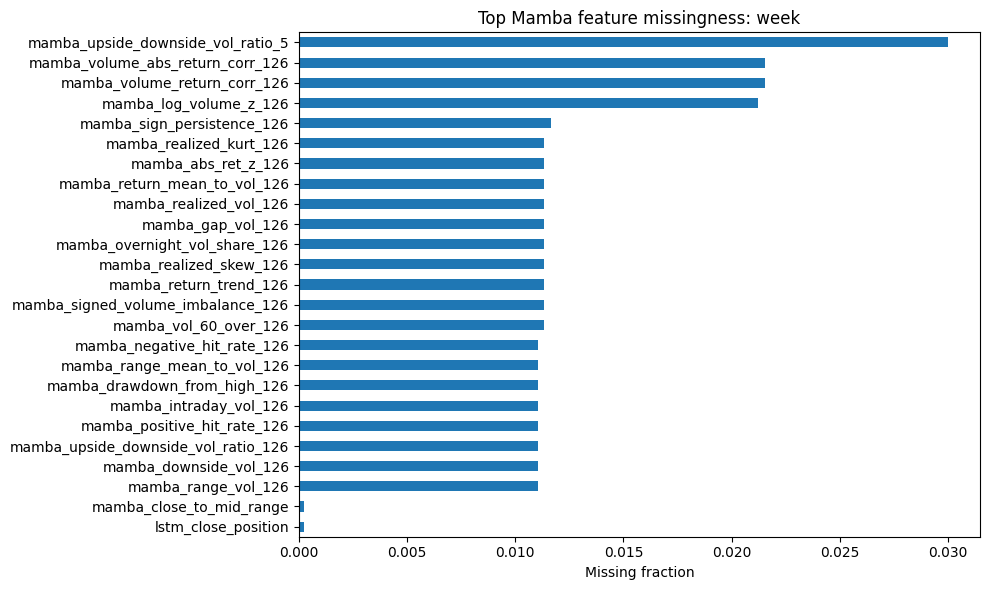

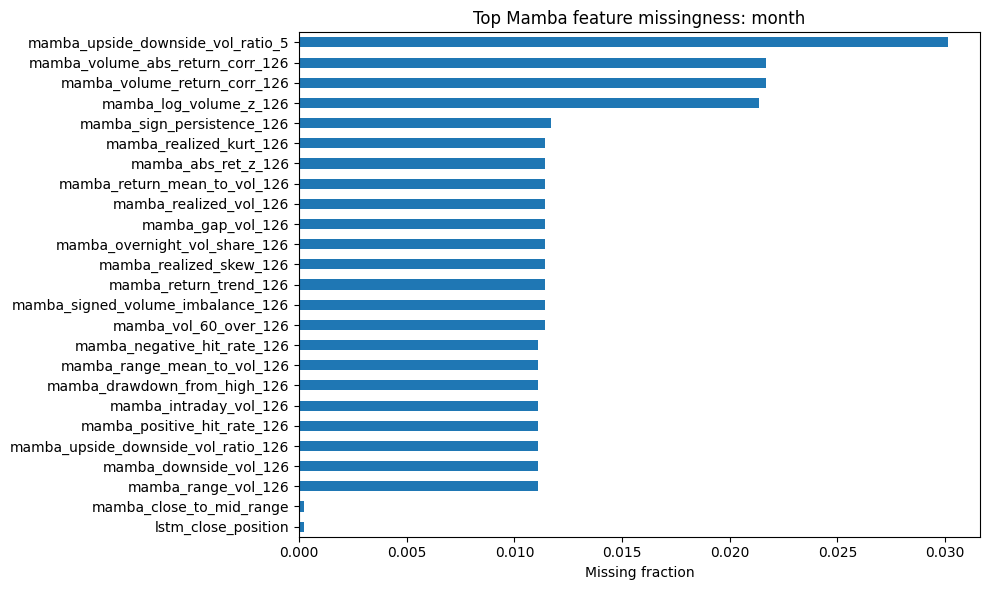

,horizon_name,horizon,rows_model_dataset,tickers,mamba_all_features,mamba_stationary_features,added_mamba_feature_count,sequences_lookback_126,target_column,model_dataset,feature_columns,sequence_diagnostics
0,week,5,19407,7,275,258,108,18532,target_return_5_next_open,artifacts/data/mamba/horizons/week/model_datas...,artifacts/data/mamba/horizons/week/feature_col...,artifacts/data/mamba/horizons/week/mamba_seque...
1,month,21,19295,7,275,258,108,18420,target_return_21_next_open,artifacts/data/mamba/horizons/month/model_data...,artifacts/data/mamba/horizons/month/feature_co...,artifacts/data/mamba/horizons/month/mamba_sequ...


In [4]:
clean_ohlcv = load_table(DATA_DIR / "clean_ohlcv.parquet")
clean_ohlcv["date"] = pd.to_datetime(clean_ohlcv["date"])
mamba_featured = make_mamba_features(clean_ohlcv)
mamba_added_cols = [col for col in mamba_featured.columns if col.startswith("mamba_")]

mamba_artifacts = []
mamba_summaries = {}

for spec in HORIZONS:
    horizon_name = spec["name"]
    horizon = int(spec["horizon"])
    global_dir = GLOBAL_LSTM_DATA_DIR / "horizons" / horizon_name
    model_path = global_dir / "model_dataset.parquet"
    feature_path = global_dir / "feature_columns.json"
    if not model_path.exists() and not model_path.with_suffix(".csv").exists():
        raise FileNotFoundError(f"Missing global LSTM data for {horizon_name}. Run notebooks/01c_global_lstm_eda.ipynb first.")

    model_df = load_table(model_path)
    model_df["date"] = pd.to_datetime(model_df["date"])
    payload = load_json(feature_path)
    target_col = payload["target_column"]
    global_feature_sets = payload["global_feature_sets"]

    mamba_model_df = model_df.merge(
        mamba_featured[["date", "ticker", *mamba_added_cols]],
        on=["date", "ticker"],
        how="left",
    )
    mamba_all = get_mamba_feature_columns(mamba_model_df, global_feature_sets["global_all"])
    mamba_stationary = stationary_mamba_feature_columns(
        get_mamba_feature_columns(mamba_model_df, global_feature_sets["global_stationary"])
    )
    feature_sets = {
        "mamba_all": mamba_all,
        "mamba_stationary": mamba_stationary,
    }

    out_dir = MAMBA_DATA_DIR / "horizons" / horizon_name
    saved_model_path = save_table(mamba_model_df, out_dir / "model_dataset.parquet")
    mamba_payload = {
        **payload,
        "feature_source": "01d_mamba_eda",
        "source_global_lstm_feature_sets": list(global_feature_sets),
        "mamba_added_feature_columns": mamba_added_cols,
        "mamba_feature_sets": feature_sets,
        "primary_mamba_feature_set": "mamba_stationary",
        "mamba_feature_family_counts": {name: mamba_feature_family_counts(cols) for name, cols in feature_sets.items()},
        "scaler_policy": "fit median imputer and RobustScaler inside each strict global train/refit split only",
        "target_normalization_policy": "global protocol tunes global vs per_ticker target normalization; default per_ticker",
        "recommended_lookbacks": RECOMMENDED_LOOKBACKS,
    }
    save_json(mamba_payload, out_dir / "feature_columns.json")

    diagnostics = {
        name: mamba_sequence_diagnostics(
            mamba_model_df,
            feature_cols=cols,
            target_col=target_col,
            lookbacks=RECOMMENDED_LOOKBACKS,
        )
        for name, cols in feature_sets.items()
    }
    diagnostics["horizon_name"] = horizon_name
    diagnostics["horizon"] = horizon
    diagnostics["target_column"] = target_col
    save_json(diagnostics, out_dir / "mamba_sequence_diagnostics.json")

    missingness = mamba_model_df[mamba_stationary].isna().mean().sort_values(ascending=False).head(25)
    fig, ax = plt.subplots(figsize=(10, 6))
    missingness.sort_values().plot(kind="barh", ax=ax)
    ax.set_title(f"Top Mamba feature missingness: {horizon_name}")
    ax.set_xlabel("Missing fraction")
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"{horizon_name}_mamba_feature_missingness.png", dpi=150, bbox_inches="tight")
    plt.show()

    rows_by_ticker = pd.DataFrame(diagnostics["mamba_stationary"]["rows_by_ticker"])
    total_sequences_126 = int(rows_by_ticker.get("sequences_lookback_126", pd.Series(dtype=float)).sum())
    mamba_artifacts.append({
        "horizon_name": horizon_name,
        "horizon": horizon,
        "rows_model_dataset": int(len(mamba_model_df)),
        "tickers": int(mamba_model_df["ticker"].nunique()),
        "mamba_all_features": len(mamba_all),
        "mamba_stationary_features": len(mamba_stationary),
        "added_mamba_feature_count": len(mamba_added_cols),
        "sequences_lookback_126": total_sequences_126,
        "target_column": target_col,
        "model_dataset": str(saved_model_path.relative_to(PROJECT_DIR)),
        "feature_columns": str((out_dir / "feature_columns.json").relative_to(PROJECT_DIR)),
        "sequence_diagnostics": str((out_dir / "mamba_sequence_diagnostics.json").relative_to(PROJECT_DIR)),
    })
    mamba_summaries[horizon_name] = diagnostics

summary = {
    "source_notebook": "01d_mamba_eda.ipynb",
    "source_global_lstm_notebook": "01c_global_lstm_eda.ipynb",
    "horizons": HORIZONS,
    "feature_sets": ["mamba_all", "mamba_stationary"],
    "recommended_lookbacks": RECOMMENDED_LOOKBACKS,
    "artifacts": mamba_artifacts,
}
save_json(summary, REPORTS_DIR / "mamba_eda_summary.json")
display(pd.DataFrame(mamba_artifacts))

## Sequence Feasibility Diagnostics

In [5]:
for horizon_name, diagnostics in mamba_summaries.items():
    print(f"=== {horizon_name}: Mamba stationary sequence feasibility ===")
    display(pd.DataFrame(diagnostics["mamba_stationary"]["rows_by_ticker"]))
    print("Feature family counts:")
    display(pd.Series(diagnostics["mamba_stationary"]["mamba_feature_family_counts"]).to_frame("count"))

=== week: Mamba stationary sequence feasibility ===


,ticker,rows,date_start,date_end,max_feasible_lookback,sequences_lookback_60,sequences_lookback_90,sequences_lookback_126,sequences_lookback_252
0,CBOM,2758,2015-11-09,2026-06-07,252,2699,2669,2633,2507
1,MBNK,537,2024-09-05,2026-06-07,252,478,448,412,286
2,SBER,4629,2007-11-28,2026-06-07,252,4570,4540,4504,4378
3,SBERP,4629,2007-11-28,2026-06-07,252,4570,4540,4504,4378
4,SVCB,636,2024-04-27,2026-06-07,252,577,547,511,385
5,T,1633,2020-03-13,2026-06-07,252,1574,1544,1508,1382
6,VTBR,4585,2008-02-01,2026-06-07,252,4526,4496,4460,4334


Feature family counts:


,count
gap_intraday,20
return_regime,32
volatility_shape,41
volume_imbalance,0
other_mamba,7


=== month: Mamba stationary sequence feasibility ===


,ticker,rows,date_start,date_end,max_feasible_lookback,sequences_lookback_60,sequences_lookback_90,sequences_lookback_126,sequences_lookback_252
0,CBOM,2742,2015-11-09,2026-05-22,252,2683,2653,2617,2491
1,MBNK,521,2024-09-05,2026-05-22,252,462,432,396,270
2,SBER,4613,2007-11-28,2026-05-22,252,4554,4524,4488,4362
3,SBERP,4613,2007-11-28,2026-05-22,252,4554,4524,4488,4362
4,SVCB,620,2024-04-27,2026-05-22,252,561,531,495,369
5,T,1617,2020-03-13,2026-05-22,252,1558,1528,1492,1366
6,VTBR,4569,2008-02-01,2026-05-22,252,4510,4480,4444,4318


Feature family counts:


,count
gap_intraday,20
return_regime,32
volatility_shape,41
volume_imbalance,0
other_mamba,7


## Target And Missingness Diagnostics

In [6]:
for horizon_name, diagnostics in mamba_summaries.items():
    print(f"=== {horizon_name}: target distribution ===")
    display(pd.Series(diagnostics["mamba_stationary"]["target_distribution"]).to_frame("value"))
    print(f"=== {horizon_name}: top feature missingness ===")
    display(pd.Series(diagnostics["mamba_stationary"]["top_feature_missingness"]).to_frame("missing_fraction"))

=== week: target distribution ===


,value
count,19407.000000
mean,0.000654
std,0.057441
min,-0.826040
p25,-0.021111
median,0.001016
p75,0.023865
max,0.584459


=== week: top feature missingness ===


,missing_fraction
mamba_upside_downside_vol_ratio_5,0.029989
mamba_volume_abs_return_corr_126,0.021539
mamba_volume_return_corr_126,0.021539
mamba_log_volume_z_126,0.021229
mamba_sign_persistence_126,0.011645
mamba_abs_ret_z_126,0.011336
mamba_return_mean_to_vol_126,0.011336
mamba_realized_vol_126,0.011336
mamba_gap_vol_126,0.011336
mamba_overnight_vol_share_126,0.011336


=== month: target distribution ===


,value
count,19295.000000
mean,0.002706
std,0.115971
min,-1.129788
p25,-0.044760
median,0.006187
p75,0.058624
max,0.687158


=== month: top feature missingness ===


,missing_fraction
mamba_upside_downside_vol_ratio_5,0.030111
mamba_volume_abs_return_corr_126,0.021664
mamba_volume_return_corr_126,0.021664
mamba_log_volume_z_126,0.021353
mamba_sign_persistence_126,0.011713
mamba_abs_ret_z_126,0.011402
mamba_return_mean_to_vol_126,0.011402
mamba_realized_vol_126,0.011402
mamba_gap_vol_126,0.011402
mamba_overnight_vol_share_126,0.011402
